In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import csv
from matplotlib import pyplot as plt
import pandas as pd
from pathlib import Path
import torch
from torchvision import datasets, transforms
from tqdm import tqdm
import numpy as np
import random
import re
from sklearn.linear_model import LinearRegression
from scipy import stats
from scipy.stats import truncnorm

import src.architectures.networkArchitectures as netArch # Assuming this is where your registry code lives
from src.robustness.general_classes import ModelBridge
from src.robustness.milp_functions import *
from src.architectures.networkArchitectures import networkRegistry
from src.robustness.exactRobustness import exactRobustness
from src.robustness.fastLin import fastLin
from src.testing.networkTesting import testNetwork
from src.training.networkTraining import trainNetwork, saveNetwork
from src.utils.extractParams import extractParams
from src.utils.loadNetwork import loadNetwork

In [2]:
# Loads the data
transform = transforms.ToTensor()
test_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
all_images = test_data.data.numpy()   # (10000, 28, 28)
all_labels = test_data.targets.numpy() # (10000,)


# 🧪 Experiment 1 — Robustness Analysis

**Goal:**  
Analyze the robustness of MNIST samples and how it relates to network architecture.

---

### Setup

- Classes considered: **0, 1, 3**
- Norm used: **L1**

This setup will remain consistent throughout the experiments

---

### Procedure

1. **Fast approximation (FastLin)**
   - Test `numberOfFastLinImages` samples per class
   - Applied to each network

2. **Exact computation**
   - Test `numberOfExactImages` samples per class
   - Applied to each network

3. **Data analysis** (not yet done)
   - Plot histogram of the robustness results per class (exact and fastlin side by side)
   - Fit least-square lines (or polynomials or something) to robustness vs number of neurons and robustness vs number of layers
   - Covariance between number of layers vs robustness and number of neurons
   - Fit linear approximator
---

### ⚠️ Note

FastLin is much faster than exact methods.  
👉 It is recommended to use fewer samples for the exact computations.

In [3]:
classes_to_test = (0, 1, 3)
pNorm = 1

## FastLin Testing of MNIST

In [4]:
numberOfFastLinImages = 100 # Per class per network

# Where to place results
resultsDirectory = Path("results")
fileName = "Exp1FastLinRobustnessResults.csv"
filePath = resultsDirectory / fileName

# Load already completed results
if filePath.exists():
    df = pd.read_csv(filePath)
    computedResults = set(zip(df["name"], df["imageIndex"], df["pNorm"]))
else:
    computedResults = set()

# Open CSV for appending
fileExists = filePath.exists()

with filePath.open(mode = "a", newline = "") as file:
    writer = csv.writer(file)

    # Create header if file does not already exist
    if not fileExists:
        writer.writerow(["name", "imageIndex", "label", "predictedClass", "pNorm", "epsilon"])

    for networkName in networkRegistry:
        print(networkName)
        print(f"Computing Fast-Lin for network: {networkName} (pNorm = {pNorm})")
        network = loadNetwork(networkName)

        parameters = extractParams(network = network, inputShape = (1, 28, 28))
        weights = [W for W, _ in parameters]
        biases = [b for _, b in parameters]

        for cls in classes_to_test:
            indices = np.where(all_labels == cls)[0]            
            selected_indices = random.sample(list(indices), min(numberOfFastLinImages, len(indices)))

            for imageIndex in tqdm(selected_indices):
                # Skip image if already computed for the network using Fast-Lin
                if (networkName, imageIndex, pNorm, False) in computedResults:
                    continue

                # Compute results
                image, label = test_data[imageIndex]
                x0 = image.view(-1).numpy()

                output = network(image)
                _, predictedClass = torch.max(output, 1)
                predictedClass = predictedClass.item()
                targetClasses = [targetClass for targetClass in range(0, 10) if targetClass != predictedClass]
                
                certifiedEpsilon, _, _ = fastLin(weights = weights, biases = biases, x0 = x0, pNorm = pNorm, epsilon0 = 10, originalClass = predictedClass, targetClasses = targetClasses, tolerance = 0.005)

                # Save computed results
                writer.writerow([networkName, imageIndex, label, predictedClass, pNorm, certifiedEpsilon])
                file.flush()

Dense1x15
Computing Fast-Lin for network: Dense1x15 (pNorm = 1)


 46%|████▌     | 46/100 [00:03<00:03, 14.57it/s]


KeyboardInterrupt: 

## Exact testing of MNIST

In [4]:
numberOfExactImages = 5 # Per class per network
timeLimit = 300 # seconds

# Where to place results
resultsDir = Path("results")
resultsDir.mkdir(exist_ok=True)
filePath = resultsDir / "Exp1ExactRobustnessResults.csv"
fastLinPath = resultsDir / "Exp1FastLinRobustnessResults.csv"

# Load already computed results (Network, ImageIndex) to avoid duplicates
computed_pairs = set()
computed_counts = {}    # (network, class) -> count
if filePath.exists() and filePath.stat().st_size > 0:
    df_old = pd.read_csv(filePath)
    computed_pairs = set(zip(df_old["name"], df_old["imageIndex"]))
    for _, row in df_old.iterrows():
        key = (row["name"], row["label"])
        computed_counts[key] = computed_counts.get(key, 0) + 1

# We are going to test a subset of the samples tested through fastLin, so we load that data
fastlin_indices = {}
if fastLinPath.exists():
    df_fl = pd.read_csv(fastLinPath)
    for net in df_fl["name"].unique():
        fastlin_indices[net] = df_fl[df_fl["name"] == net]["imageIndex"].tolist()


with filePath.open(mode="a", newline="") as file:
    writer = csv.writer(file)
    if not filePath.exists() or filePath.stat().st_size == 0:
        writer.writerow(["name", "imageIndex", "label", "predictedClass", "pNorm", "finishedSearch", "epsilon"])
    for networkName, entry in netArch.networkRegistry.items():
        if "big" in entry.tags:
            print(f"\n --- Skipped big network: {networkName} ---")
            continue

        # Skips network if we already have enough results
        enoughResults = True
        for cls in classes_to_test:
            if computed_counts.get((networkName, cls), 0) < numberOfExactImages:
                enoughResults = False
                break

        if enoughResults:
            print(f"\n --- Skipped network: {networkName}, already has enough results ---")
            continue

        print(f"\n--- Initializing Network Template: {networkName} ---")
        
        # Load the network 
        NetworkClass = netArch.networkRegistry[networkName].NetworkClass
        model_pt = NetworkClass()
        model_pt.load_state_dict(torch.load(f'networks/{networkName}.pth', map_location='cpu'))
        model_pt.eval()
        bridge = ModelBridge(model_pt, time_limit = timeLimit)
        bridge.load_layers_from_pytorch_model(L0=0, U0=1, input_shape=(784,))
        # The first layer will be bound tightened exactly. Only worth it if alot of samples are tested.
        bridge.layers[0].do_exact_bound_tightening() 
        bridge.setup_gurobi_logic()
        
        # We will only use the gurobi model in this state to copy it later, the template variable is just for clarity 
        template_model = bridge.gurobi_model 

        for cls in classes_to_test:
            # Only tests the amount of needed results
            computedResults = computed_counts.get((networkName, cls), 0)
            neededResults = numberOfExactImages - computedResults
            if neededResults <= 0:
                continue

            # Selects the correct samples to test
            pool = [idx for idx in fastlin_indices.get(networkName, []) if all_labels[idx] == cls]
            if not pool: pool = np.where(all_labels == cls)[0].tolist()
            pool = [idx for idx in pool if (networkName, idx) not in computed_pairs]
            if not pool: continue
            selected_indices = random.sample(pool, min(neededResults, len(pool)))

            for idx in selected_indices:
                try:
                    img_flat_np = all_images[idx].flatten().astype(np.float32) / 255.0
                    label = int(all_labels[idx])

                    # Computes the networks classification of the unperturbed sample
                    img_torch = torch.from_numpy(img_flat_np).unsqueeze(0)
                    with torch.no_grad():
                        output = model_pt(img_torch)
                        predicted_class = int(torch.argmax(output, dim=1).item())

                    # Each robustness test introduces new variables to the model.
                    # Therefore we make a copy of the template so as to not optimize redundant variables
                    sample_model = template_model.copy()
                                    
                    # Add sample-specific robustness constraints and variables and objective to the copy
                    robustness_setup(img_flat_np, label, bridge, g_model=sample_model, max_d=1.0)

                    # The main test
                    eps, _, _ = standard_robustness_test(bridge, g_model=sample_model)  
                    if eps is None:
                        finished_search = False
                        eps = -1
                    else: finished_search = True
                
                    writer.writerow([networkName, int(idx), label, predicted_class, pNorm, finished_search, float(eps)])
                    file.flush()

                    if finished_search: 
                        print(f"  [Success] {networkName} Idx {idx}: Eps {eps:.4f}")
                    else:
                        print(f"  [Failure] {networkName} Idx {idx}: timed-out after {timeLimit} seconds")
                    # Explicitly dispose of the copy to free up memory
                    sample_model.dispose() 

                except Exception as e:
                    print(f"  [Error] {networkName} Idx {idx}: {e}")


 --- Skipped network: Dense1x15, already has enough results ---

 --- Skipped network: Dense1x20, already has enough results ---

 --- Skipped network: Dense1x25, already has enough results ---

 --- Skipped network: Dense1x30, already has enough results ---

 --- Skipped network: Dense1x35, already has enough results ---

 --- Skipped network: Dense1x40, already has enough results ---

 --- Skipped network: Dense1x45, already has enough results ---

 --- Skipped network: Dense1x50, already has enough results ---

 --- Skipped network: Dense1x55, already has enough results ---

 --- Skipped network: Dense1x60, already has enough results ---

 --- Skipped network: Dense1x65, already has enough results ---

 --- Skipped network: Dense1x70, already has enough results ---

 --- Skipped network: Dense2x20, already has enough results ---

 --- Skipped network: Dense2x25, already has enough results ---

 --- Skipped network: Dense2x30, already has enough results ---

 --- Skipped network: De

Setting up neuron 20: 100%|██████████| 20/20 [00:02<00:00,  8.02it/s]


Optimal solution found!
  [Success] Dense4x20 Idx 2127: Eps 5.9747
Optimal solution found!
  [Success] Dense4x20 Idx 2899: Eps 6.7013
No solution found
  [Failure] Dense4x20 Idx 6789: timed-out after 300 seconds
No solution found
  [Failure] Dense4x20 Idx 984: timed-out after 300 seconds
Optimal solution found!
  [Success] Dense4x20 Idx 1067: Eps 4.2694
Optimal solution found!
  [Success] Dense4x20 Idx 7131: Eps 6.3565

--- Initializing Network Template: Dense4x25 ---


Setting up neuron 25: 100%|██████████| 25/25 [00:02<00:00,  8.62it/s]


Optimal solution found!
  [Success] Dense4x25 Idx 884: Eps 3.9231
Optimal solution found!
  [Success] Dense4x25 Idx 5731: Eps 3.0488
No solution found
  [Failure] Dense4x25 Idx 3843: timed-out after 300 seconds
No solution found
  [Failure] Dense4x25 Idx 419: timed-out after 300 seconds
Optimal solution found!
  [Success] Dense4x25 Idx 6023: Eps 2.7671
Optimal solution found!
  [Success] Dense4x25 Idx 734: Eps 2.7476

 --- Skipped big network: Dense4x30 ---

 --- Skipped big network: Dense4x35 ---

 --- Skipped big network: Dense4x40 ---

 --- Skipped big network: Dense4x45 ---

 --- Skipped big network: Dense4x50 ---

 --- Skipped big network: Dense4x55 ---

 --- Skipped big network: Dense4x60 ---

 --- Skipped big network: Dense4x65 ---

 --- Skipped big network: Dense4x70 ---

--- Initializing Network Template: Dense5x20 ---


Setting up neuron 20: 100%|██████████| 20/20 [00:02<00:00,  8.85it/s]


Optimal solution found!
  [Success] Dense5x20 Idx 3412: Eps 4.1299
No solution found
  [Failure] Dense5x20 Idx 3608: timed-out after 300 seconds
No solution found
  [Failure] Dense5x20 Idx 1715: timed-out after 300 seconds
No solution found
  [Failure] Dense5x20 Idx 918: timed-out after 300 seconds
Optimal solution found!
  [Success] Dense5x20 Idx 6982: Eps 3.2133
Optimal solution found!
  [Success] Dense5x20 Idx 1109: Eps 7.4869

 --- Skipped big network: Dense5x25 ---

 --- Skipped big network: Dense5x30 ---

 --- Skipped big network: Dense5x35 ---

 --- Skipped big network: Dense5x40 ---

 --- Skipped big network: Dense5x45 ---

 --- Skipped big network: Dense5x50 ---

 --- Skipped big network: Dense5x55 ---

 --- Skipped big network: Dense5x60 ---

 --- Skipped big network: Dense5x65 ---

 --- Skipped big network: Dense5x70 ---

 --- Skipped big network: Dense6x25 ---

 --- Skipped big network: Dense6x30 ---

 --- Skipped big network: Dense6x35 ---

 --- Skipped big network: Dense6

## Data Analysis

In [5]:
SET_MISCLASSIFIED_TO_ZERO = False # Otherwise ignore them

# Load results
df_exact = pd.read_csv("results/Exp1ExactRobustnessResults.csv")
df_exact = df_exact[df_exact["finishedSearch"] == True]
df_fast = pd.read_csv("results/Exp1FastLinRobustnessResults.csv")


# Handle Misclassifications
if SET_MISCLASSIFIED_TO_ZERO:
    # Set epsilon to 0 where prediction != label
    df_exact.loc[df_exact['predictedClass'] != df_exact['label'], 'epsilon'] = 0.0
    df_fast.loc[df_fast['predictedClass'] != df_fast['label'], 'epsilon'] = 0.0
    print(f"Mode: Misclassifications set to 0.0")
else:
    # Filter out misclassifications
    df_exact = df_exact[df_exact['predictedClass'] == df_exact['label']]
    df_fast = df_fast[df_fast['predictedClass'] == df_fast['label']]
    print(f"Mode: Misclassifications removed from dataset")

# Update the classes list for subsequent plots
classes = sorted(df_exact['label'].unique())

print(f"Filters applied. Samples - Exact: {len(df_exact)}, Fast-Lin: {len(df_fast)}")

Mode: Misclassifications removed from dataset
Filters applied. Samples - Exact: 336, Fast-Lin: 19105


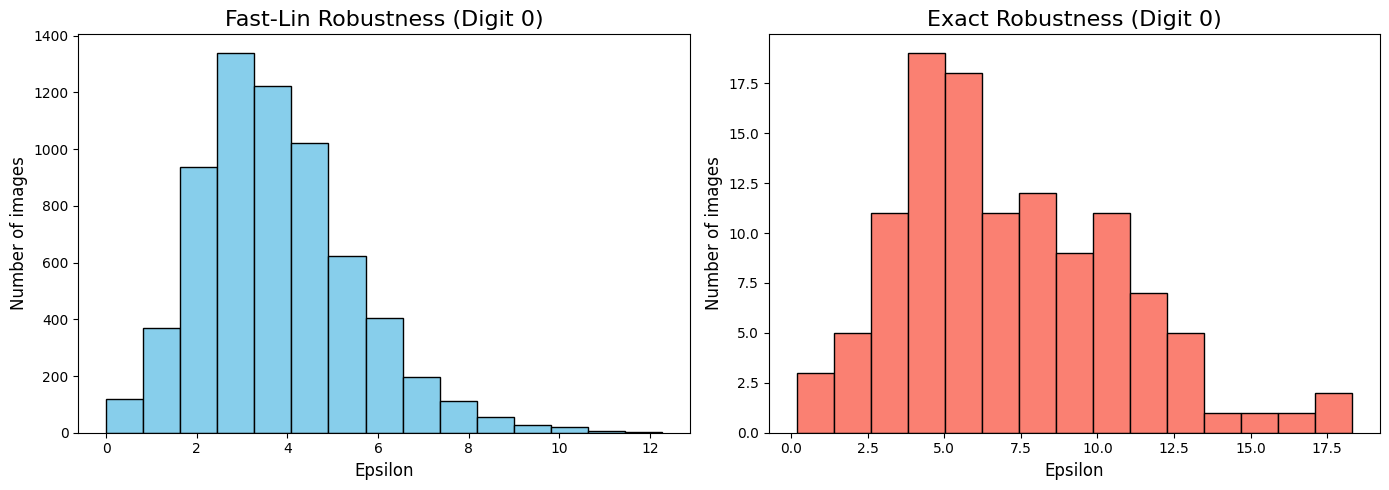

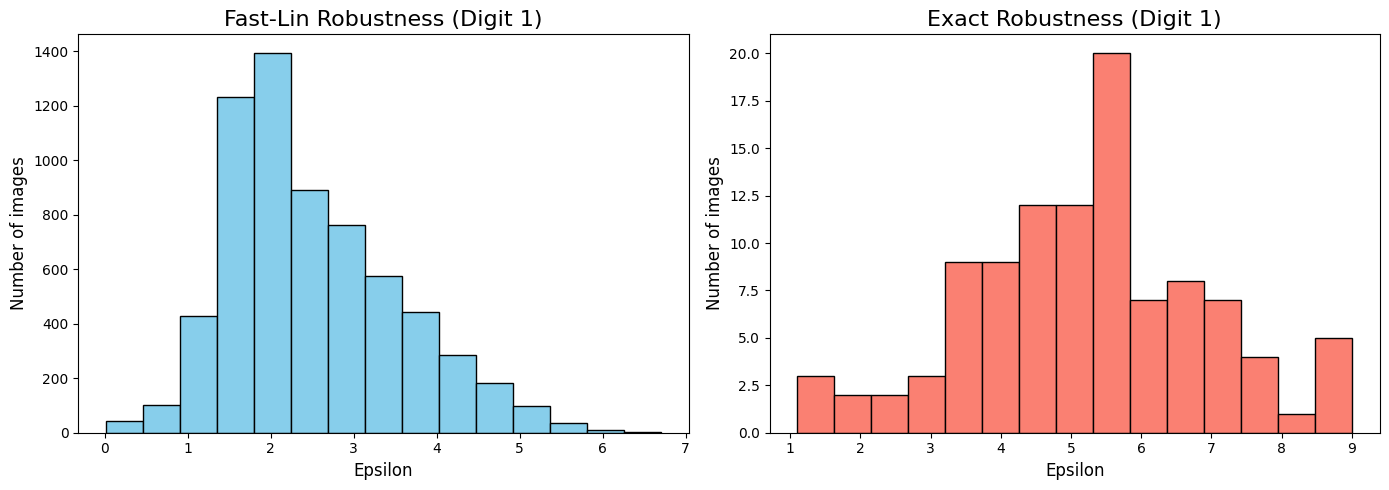

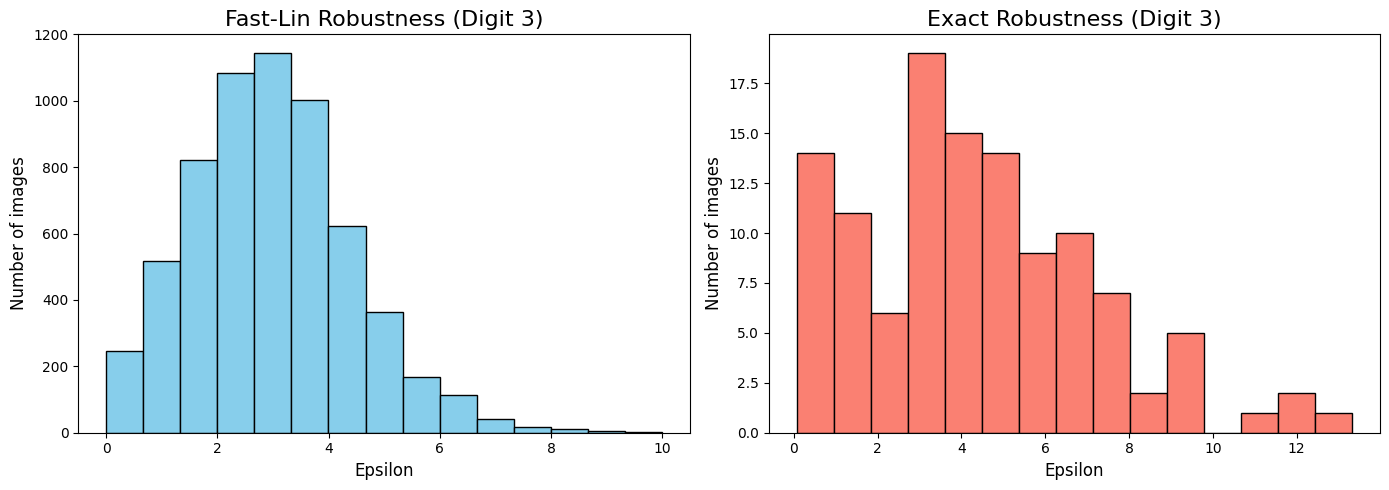

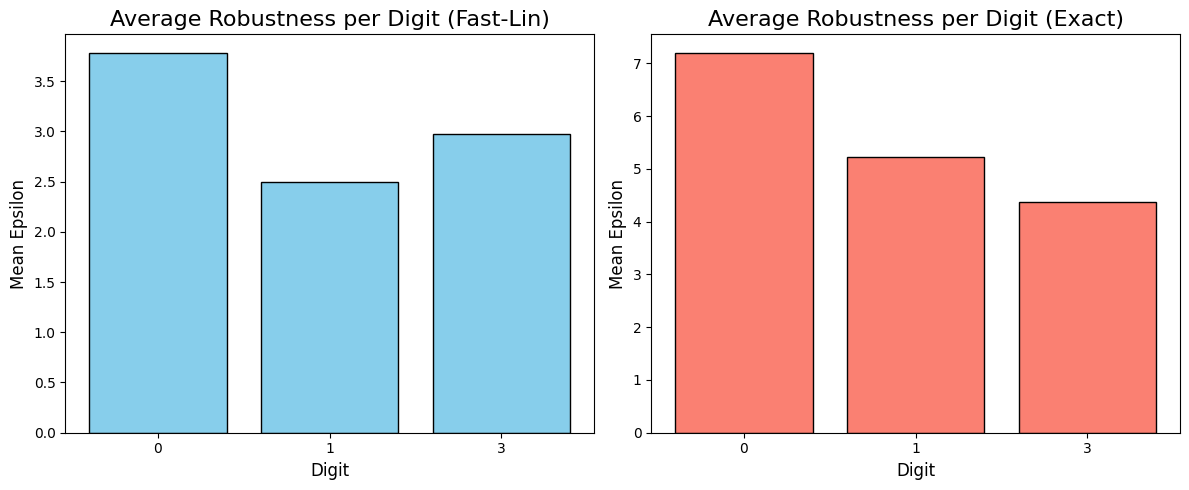

--- Robustness Variances ---
Class 0 | Fast-Lin Var: 2.919052 | Exact Var: 13.384564
Class 1 | Fast-Lin Var: 1.068547 | Exact Var: 2.868228
Class 3 | Fast-Lin Var: 2.045968 | Exact Var: 7.798299


In [19]:
n_bins = 15

# --- Histograms with Truncated Normal Overlay ---
for cls in classes:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    datasets = [
        (df_fast[df_fast['label'] == cls]['epsilon'], ax1, "Fast-Lin", "skyblue"),
        (df_exact[df_exact['label'] == cls]['epsilon'], ax2, "Exact", "salmon")
    ]
    
    for data, ax, title, color in datasets:
        # 1. Plot the histogram
        counts, bins, _ = ax.hist(data, bins=n_bins, color=color, edgecolor='black')
        
        ax.set_title(f"{title} Robustness (Digit {cls})", fontsize = 16)
        ax.set_xlabel("Epsilon", fontsize = 12)
        ax.set_ylabel("Number of images", fontsize = 12)
    
    plt.tight_layout()
    plt.show()

# --- Average Robustness Bar Diagrams ---
avg_fast = df_fast.groupby('label')['epsilon'].mean()
var_fast = df_fast.groupby('label')['epsilon'].var()
avg_exact = df_exact.groupby('label')['epsilon'].mean()
var_exact = df_exact.groupby('label')['epsilon'].var()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.bar(avg_fast.index.astype(str), avg_fast.values, color='skyblue', edgecolor='black')
ax1.set_title("Average Robustness per Digit (Fast-Lin)", fontsize = 16)
ax1.set_xlabel("Digit", fontsize = 12)
ax1.set_ylabel("Mean Epsilon", fontsize = 12)

ax2.bar(avg_exact.index.astype(str), avg_exact.values, color='salmon', edgecolor='black')
ax2.set_title("Average Robustness per Digit (Exact)", fontsize = 16)
ax2.set_xlabel("Digit", fontsize = 12)
ax2.set_ylabel("Mean Epsilon", fontsize = 12)

plt.tight_layout()
plt.show()

print("--- Robustness Variances ---")
for cls in classes:
    print(f"Class {cls} | Fast-Lin Var: {var_fast[cls]:.6f} | Exact Var: {var_exact[cls]:.6f}")

C:\Users\Samuel Fors\AppData\Local\Temp\ipykernel_12976\204846505.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


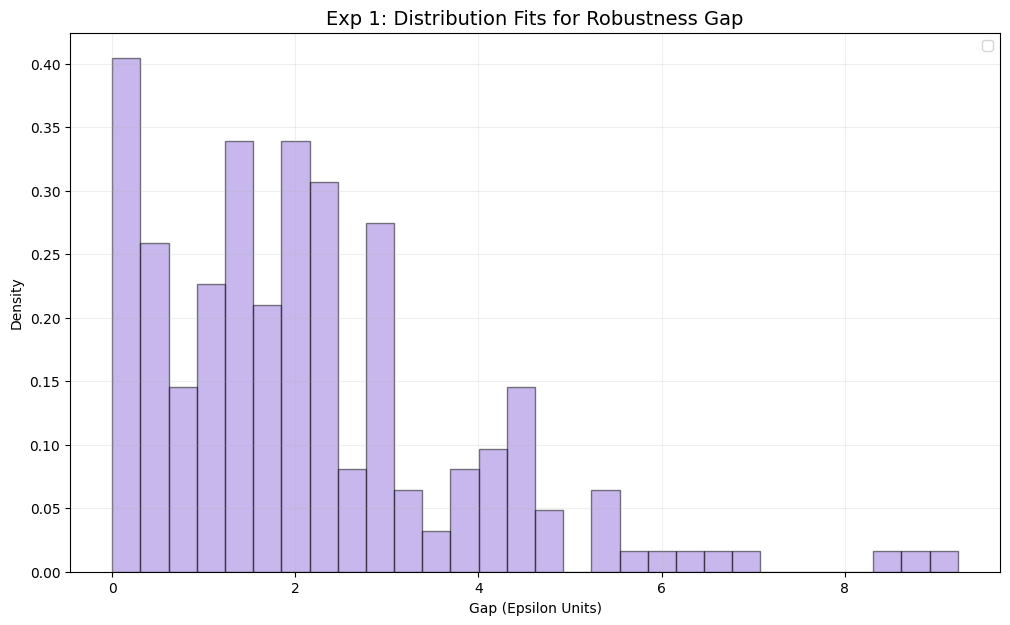

--- Fit Summary (Experiment 1) ---
Mean Gap: 2.147546
Samples at zero (approx): 0 out of 201

--- Relationship Statistics ---
Covariance (Fast-Lin vs Exact): 5.64641341
Correlation (Pearson R):       0.949990

Full Covariance Matrix:
[[ 3.20184802  5.64641341]
 [ 5.64641341 11.0333269 ]]


In [ ]:
# Align the data for Experiment 1
df_merged = pd.merge(
    df_fast[['name', 'imageIndex', 'epsilon']], 
    df_exact[['name', 'imageIndex', 'epsilon']], 
    on=['name', 'imageIndex'], 
    suffixes=('_fast', '_exact')
)

# Calculate the gap
df_merged['gap'] = (df_merged['epsilon_fast'] - df_merged['epsilon_exact']).abs()
data = df_merged['gap'].dropna()

# Setup the Plot
plt.figure(figsize=(12, 7))
counts, bins, _ = plt.hist(data, bins=30, color='mediumpurple', edgecolor='black', alpha=0.5, density=True)
x = np.linspace(0, data.max(), 200)


"""
# --- Fit 1: Exponential ---
loc_ex, scale_ex = stats.expon.fit(data, floc=0) 
plt.plot(x, stats.expon.pdf(x, loc_ex, scale_ex), color='green', lw=3, 
         label=f'Exponential (λ={1/scale_ex:.2f})')

# --- Fit 2: Half-Normal ---
loc_hn, scale_hn = stats.halfnorm.fit(data)
plt.plot(x, stats.halfnorm.pdf(x, loc_hn, scale_hn), color='blue', lw=3, 
         label=f'Half-Normal (σ={scale_hn:.3f})')

# --- Fit 3: Truncated Normal ---
mu_guess, std_guess = data.mean(), data.std()
a_bound = (0 - mu_guess) / std_guess
plt.plot(x, stats.truncnorm.pdf(x, a_bound, np.inf, loc=mu_guess, scale=std_guess), 
         color='red', lw=3, label=f'Truncated Normal (μ={mu_guess:.3f}, σ={std_guess:.3f})')
"""
# 3. Finalize Plot
plt.title("Exp 1: Distribution Fits for Robustness Gap", fontsize=14)
plt.xlabel("Gap (Epsilon Units)")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# 4. Statistics & Covariance
# Calculate Covariance Matrix between the two epsilon columns
cov_matrix = np.cov(df_merged['epsilon_fast'], df_merged['epsilon_exact'])
covariance_val = cov_matrix[0, 1]
correlation_val = df_merged['epsilon_fast'].corr(df_merged['epsilon_exact'])

print(f"--- Fit Summary (Experiment 1) ---")
print(f"Mean Gap: {data.mean():.6f}")
print(f"Samples at zero (approx): {len(data[data < 1e-5])} out of {len(data)}")

print(f"\n--- Relationship Statistics ---")
print(f"Covariance (Fast-Lin vs Exact): {covariance_val:.8f}")
print(f"Correlation (Pearson R):       {correlation_val:.6f}")
print("\nFull Covariance Matrix:")
print(cov_matrix)

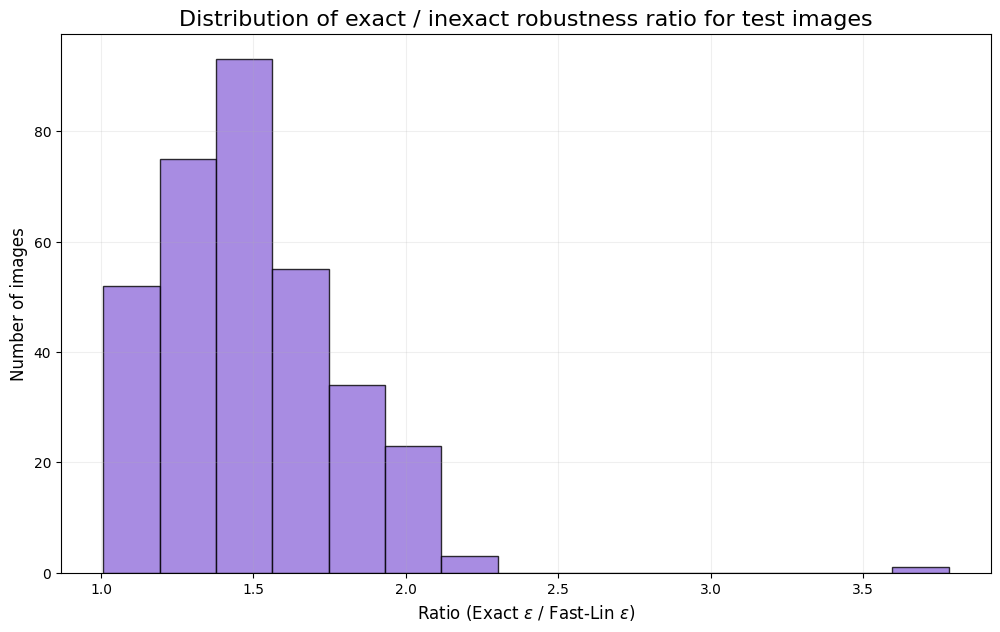

--- Fit Summary (Experiment 1) ---
Mean Gap: 1.489038
Samples at zero (approx): 0 out of 336

--- Relationship Statistics ---
Covariance (Fast-Lin vs Exact): 4.94899972
Correlation (Pearson R):       0.944790

Full Covariance Matrix:
[[2.86073608 4.94899972]
 [4.94899972 9.59149938]]


In [33]:
# Align the data for Experiment 1
df_merged = pd.merge(
    df_fast[['name', 'imageIndex', 'epsilon']], 
    df_exact[['name', 'imageIndex', 'epsilon']], 
    on=['name', 'imageIndex'], 
    suffixes=('_fast', '_exact')
)

# Calculate the gap
df_merged['ratio'] = (df_merged['epsilon_exact'] / df_merged['epsilon_fast'])
data = df_merged['ratio'].dropna()

# Setup the Plot
plt.figure(figsize=(12, 7))
counts, bins, _ = plt.hist(data, bins=15, color='mediumpurple', alpha=0.8, edgecolor='black', density=False)

"""
x = np.linspace(0, data.max(), 200)
# --- Fit 1: Exponential ---
loc_ex, scale_ex = stats.expon.fit(data, floc=0) 
plt.plot(x, stats.expon.pdf(x, loc_ex, scale_ex), color='green', lw=3, 
         label=f'Exponential (λ={1/scale_ex:.2f})')

# --- Fit 2: Half-Normal ---
loc_hn, scale_hn = stats.halfnorm.fit(data)
plt.plot(x, stats.halfnorm.pdf(x, loc_hn, scale_hn), color='blue', lw=3, 
         label=f'Half-Normal (σ={scale_hn:.3f})')

# --- Fit 3: Truncated Normal ---
mu_guess, std_guess = data.mean(), data.std()
a_bound = (0 - mu_guess) / std_guess
plt.plot(x, stats.truncnorm.pdf(x, a_bound, np.inf, loc=mu_guess, scale=std_guess), 
         color='red', lw=3, label=f'Truncated Normal (μ={mu_guess:.3f}, σ={std_guess:.3f})')
"""
# 3. Finalize Plot
plt.title("Distribution of exact / inexact robustness ratio for test images", fontsize=16)
plt.xlabel("Ratio (Exact $\epsilon$ / Fast-Lin $\epsilon$)", fontsize = 12)
plt.ylabel("Number of images", fontsize = 12)
plt.grid(alpha=0.2)
plt.show()

# 4. Statistics & Covariance
# Calculate Covariance Matrix between the two epsilon columns
cov_matrix = np.cov(df_merged['epsilon_fast'], df_merged['epsilon_exact'])
covariance_val = cov_matrix[0, 1]
correlation_val = df_merged['epsilon_fast'].corr(df_merged['epsilon_exact'])

print(f"--- Fit Summary (Experiment 1) ---")
print(f"Mean Gap: {data.mean():.6f}")
print(f"Samples at zero (approx): {len(data[data < 1e-5])} out of {len(data)}")

print(f"\n--- Relationship Statistics ---")
print(f"Covariance (Fast-Lin vs Exact): {covariance_val:.8f}")
print(f"Correlation (Pearson R):       {correlation_val:.6f}")
print("\nFull Covariance Matrix:")
print(cov_matrix)

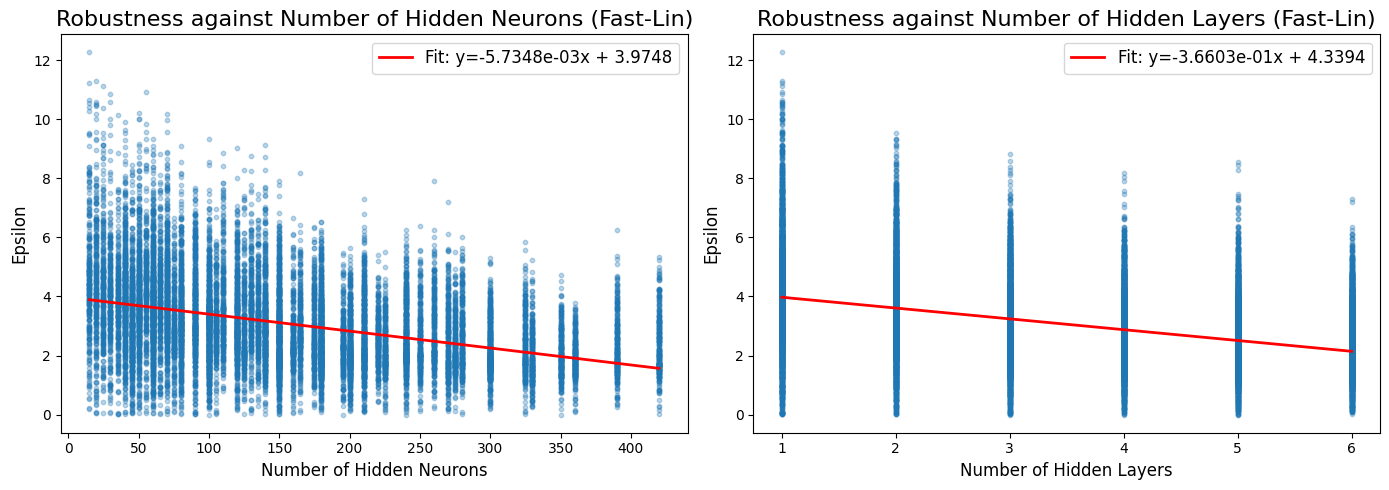

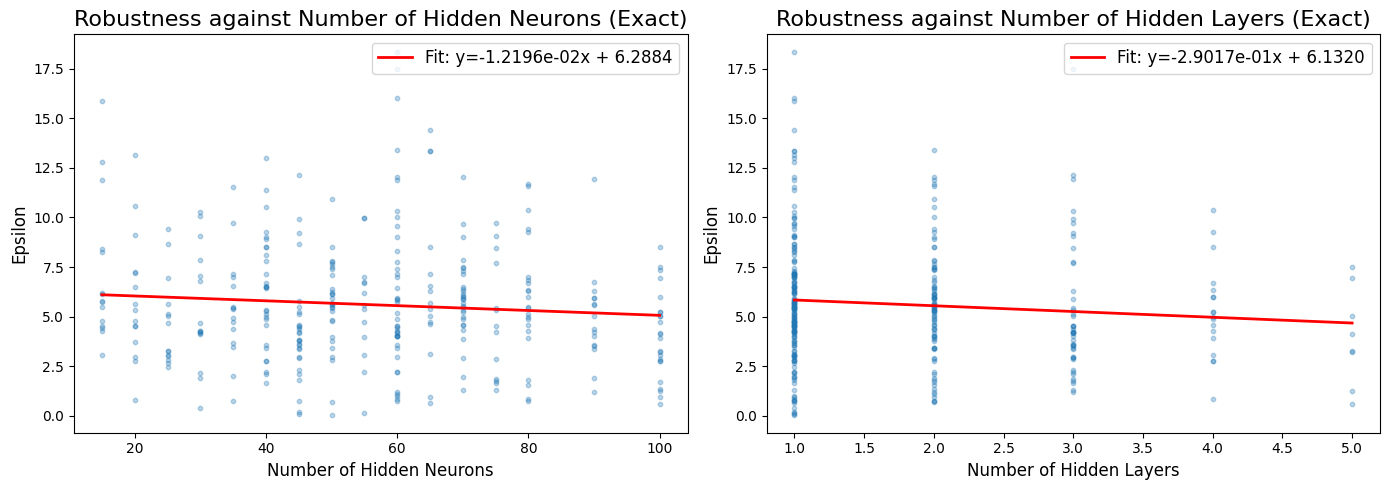

In [31]:
def extract_arch_features(name):
    # Extracts info from names like 'Dense1x60' or 'Dense3x32'
    match = re.search(r'Dense(\d+)x(\d+)', name)
    if match:
        layers = int(match.group(1))
        neurons_per_layer = int(match.group(2))
        return pd.Series({'layers': layers, 'neurons': layers * neurons_per_layer})
    return pd.Series({'layers': None, 'neurons': None})

# Helper to plot scatter with least-squares line
def plot_robustness_correlation(df, title_suffix):
    # Join architectural data
    arch_df = df['name'].apply(extract_arch_features)
    data = pd.concat([df[['epsilon']], arch_df], axis=1).dropna()
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    features = [('neurons', 'Number of Hidden Neurons'), ('layers', 'Number of Hidden Layers')]
    for ax, (feat_col, feat_label) in zip([ax1, ax2], features):
        x = data[feat_col].values
        y = data['epsilon'].values
        ax.scatter(x, y, alpha=0.3, s=10)
        
        # Calculate least-squares line
        m, c = np.polyfit(x, y, 1)
        x_range = np.array([x.min(), x.max()])
        ax.plot(x_range, m*x_range + c, color='red', lw=2, label=f'Fit: y={m:.4e}x + {c:.4f}')
        
        ax.set_title(f"Robustness against {feat_label} ({title_suffix})", fontsize = 16)
        ax.set_xlabel(feat_label, fontsize = 12)
        ax.set_ylabel("Epsilon", fontsize = 12)
        ax.legend(fontsize = 12, loc = "upper right")
    
    plt.tight_layout()
    plt.show()

plot_robustness_correlation(df_fast, "Fast-Lin")
plot_robustness_correlation(df_exact, "Exact")

In [32]:
for df, title in [(df_fast, "Fast-Lin"), (df_exact, "Exact")]:
    # Prepare data
    arch_df = df['name'].apply(extract_arch_features)
    data = pd.concat([df[['epsilon']], arch_df], axis=1).dropna()
    
    # Normalize (Standardize)
    # This makes the covariance equivalent to correlation
    norm_data = (data - data.mean()) / data.std()
    
    # Calculate Sample Covariance
    cov_matrix = norm_data.cov()
    
    print(f"\n=== {title} Statistical Analysis ===")
    print(f"Sample Covariance (Normalized):")
    print(f"  Neurons vs Robustness: {cov_matrix.loc['neurons', 'epsilon']:.4f}")
    print(f"  Layers vs Robustness:  {cov_matrix.loc['layers', 'epsilon']:.4f}")
    
    # Fit Linear Predictor: Robustness = a*(neurons) + b*(layers) + c
    X = data[['neurons', 'layers']]
    y = data['epsilon']
    
    model = LinearRegression().fit(X, y)
    a, b = model.coef_
    c = model.intercept_
    
    print(f"Best Linear Predictor:")
    print(f"  Robustness = ({a:.6f} * Neurons) + ({b:.6f} * Layers) + {c:.6f}")


=== Fast-Lin Statistical Analysis ===
Sample Covariance (Normalized):
  Neurons vs Robustness: -0.3816
  Layers vs Robustness:  -0.4129
Best Linear Predictor:
  Robustness = (-0.002095 * Neurons) + (-0.266449 * Layers) + 4.323118

=== Exact Statistical Analysis ===
Sample Covariance (Normalized):
  Neurons vs Robustness: -0.0906
  Layers vs Robustness:  -0.0958
Best Linear Predictor:
  Robustness = (-0.006789 * Neurons) + (-0.194609 * Layers) + 6.337609
